In [1]:
import numpy as np
from galpy.orbit import Orbit
from galpy.potential import KeplerPotential
import astropy.constants as acon
import astropy.units as u
import matplotlib.pyplot as plt

In [2]:
from scipy.spatial.transform import Rotation
from numpy.linalg import norm
from scipy.integrate import quad

In [4]:
num = 10000
t = 0
rs = 149600000

v_sun = np.array([12.9, 245.6, 7.78])
v_earth = np.array([0, 0, 0])
v_str = np.array([10, 0, 0])
v_c = v_str #- v_sun

normal = np.array([-v_c[1], v_c[0], 0])
rot = Rotation.from_rotvec(t * normal / norm(normal))
r = rot.apply(v_c)
r = r / norm(r) * rs



In [5]:
num = 81
points = []
z = np.linspace(-4, 4, num)

esc = np.sqrt(2 * acon.GM_sun / (rs * u.km))

for i in range(num):
    points.append([10 * rs * u.km, -esc.to(u.km / u.s), 0 * u.km / u.s, z[i] * rs * u.km, 0 * u.km / u.s, 0 * u.radian])



In [5]:
(5 * rs * u.km).to(u.kpc)

<Quantity 2.42410291e-08 kpc>

In [6]:
# 1. Initialize the orbit [R, vR, vT, z, vz, phi]
o = Orbit(points)

# 2. Define a time array for integration



tf = np.sqrt(2 * (rs * u.km) ** 3 / 3 / acon.GM_sun).to(u.s).value
ts = np.linspace(0.0, 40 * tf, 1000000) * u.s


pot = KeplerPotential(acon.GM_sun)

# 3. Solve the equations of motion
o.integrate(ts, pot)

rs_kpc = (rs * u.km).to(u.kpc).value
# 4. Plot the resulting trajectory
#plt.xlim(-1 * rs_kpc, 5 * rs_kpc)
#plt.ylim(-2, 2)

(-9.69641163401754e-09, 9.69641163401754e-09)

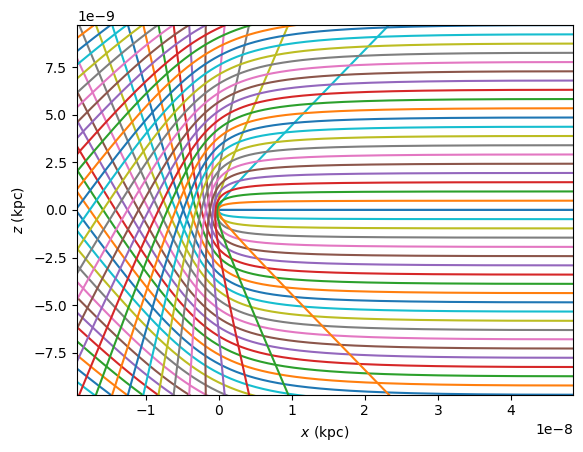

In [7]:
o.plot(d1 = 'x', d2='z')
plt.xlim(-4 * rs_kpc, 10 * rs_kpc)
plt.ylim(-2 * rs_kpc, 2 * rs_kpc)

In [7]:
orbit = o.getOrbit()


In [12]:
# [R, vR, vT, z, vz, phi]
mask_r = (orbit[:, :, 0] * np.cos(orbit[:, :, -1]))**2 + (orbit[:, :, 3])**2
mask_r = np.sqrt(mask_r)
mask_r = (mask_r < ((1.1*rs * u.km).to(u.kpc) / 8).value) * (mask_r > ((0.9*rs * u.km).to(u.kpc) / 8).value)


In [ ]:
z = orbit[:, :, 3]
x = orbit[:, :, 0] * np.cos(orbit[:, :, -1])

mask1 = np.arctan(z / x)
mask1[(x < 0) * (z > 0)] = np.pi - mask1[(x < 0) * (z > 0)]
mask1[(x < 0) * (z < 0)] = -np.pi + mask1[(x < 0) * (z < 0)]
#mask1[(x > 0) * (z < 0)] = 2* np.pi - mask1[(x > 0) * (z < 0)]

In [19]:
first = ((mask1 < np.pi / 4) * (mask1 > -np.pi/4) * mask_r).sum()
second = (((mask1 > np.pi * 3/ 4) + (mask1 < - 3 * np.pi/4)) * mask_r).sum()


In [21]:
first/second

0.6249409262759924

In [76]:
np.arctan(points[0][3] / points[0][0])

<Quantity -0.38050638 rad>

In [77]:
points[0]

[<Quantity 1.496e+09 km>,
 <Quantity -42.12161537 km / s>,
 <Quantity 0. km / s>,
 <Quantity -5.984e+08 km>,
 <Quantity 0. km / s>,
 <Quantity 0. rad>]

Text(0, 0.5, '$z/z_0$')

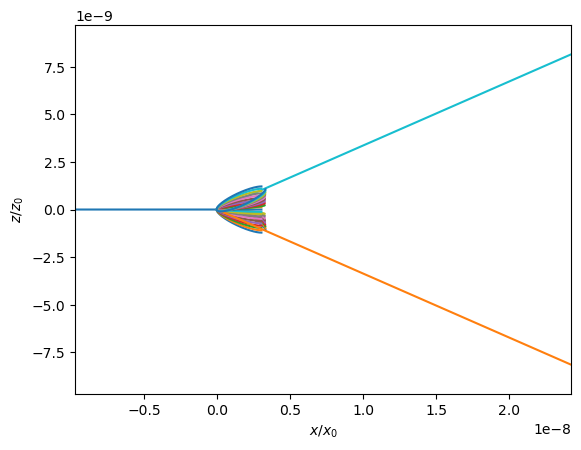

In [18]:
orbit = o.getOrbit()
R, z, phi = orbit[:, :, 0], orbit[:, :, 3], orbit[:, :, -1]

# Rp + GM/xww (2Rp + 4pi R)

plt.clf()
x = np.real(R * np.exp(1j *phi))

for i in range(num):
    plt.plot(x[i], z[i])

rs_kpc = (rs * u.km).to(u.kpc).value

plt.xlim(-2 * rs_kpc, 5 * rs_kpc)
plt.ylim(-2 * rs_kpc, 2 * rs_kpc)

plt.xlabel("$x/x_0$")
plt.ylabel("$z/z_0$")

In [19]:
orbit[:, -50000, 1]

array([5.        , 5.        , 5.        , 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.        ,
       4.99999308, 5.        , 5.        , 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.        ,
       5.        ])

In [20]:
x[1].shape

(100000,)

/home/shaurya/mambaforge/envs/ssp/lib/python3.11/site-packages/galpy/util/plot.py:494: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim3d(*ylimits)

/home/shaurya/mambaforge/envs/ssp/lib/python3.11/site-packages/galpy/util/plot.py:495: UserWarning: Attempting to set identical low and high zlims makes transformation singular; automatically expanding.
  ax.set_zlim3d(*zlimits)



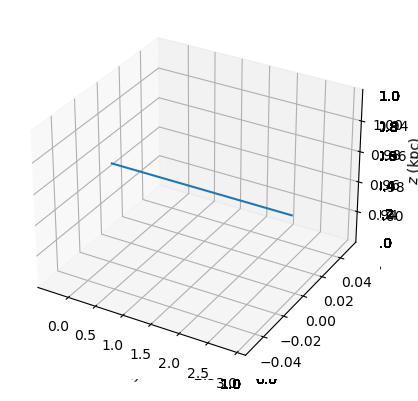

In [12]:
o.plot3d()